In [1]:
### Importing the necessary libraries.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

C:\Users\USER\anaconda3\Python\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
### Loading my dataset.

df = pd.read_csv(r'C:\Users\USER\Desktop\SQL and Excel Files\Excel files\Case Study Data - Read Only - case_study_data_2025-01-16T06_49_12.19881Z.csv')
df.head()

,DATE,ANONYMIZED CATEGORY,ANONYMIZED PRODUCT,ANONYMIZED BUSINESS,ANONYMIZED LOCATION,QUANTITY,UNIT PRICE
0,"August 18, 2024, 9:32 PM",Category-106,Product-21f4,Business-de42,Location-1ba8,1,850
1,"August 18, 2024, 9:32 PM",Category-120,Product-4156,Business-de42,Location-1ba8,2,"1,910"
2,"August 18, 2024, 9:32 PM",Category-121,Product-49bd,Business-de42,Location-1ba8,1,"3,670"
3,"August 18, 2024, 9:32 PM",Category-76,Product-61dd,Business-de42,Location-1ba8,1,"2,605"
4,"August 18, 2024, 9:32 PM",Category-119,Product-66e0,Business-de42,Location-1ba8,5,"1,480"


### DATA CLEANING

In [3]:
### Checking how many rows and columns I have.

df.shape

(333405, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333405 entries, 0 to 333404
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   DATE                 333405 non-null  object
 1   ANONYMIZED CATEGORY  333405 non-null  object
 2   ANONYMIZED PRODUCT   333405 non-null  object
 3   ANONYMIZED BUSINESS  333405 non-null  object
 4   ANONYMIZED LOCATION  333405 non-null  object
 5   QUANTITY             333405 non-null  int64 
 6   UNIT PRICE           333397 non-null  object
dtypes: int64(1), object(6)
memory usage: 17.8+ MB


In [5]:
### Checking for missing values.

df_msg = df.isnull().sum().sort_values().reset_index()

df_msg = df_msg.rename(columns={0 : 'missing_values'})

df_msg['pct'] = (df_msg['missing_values']*100)/333405

df_msg

,index,missing_values,pct
0,DATE,0,0.000000
1,ANONYMIZED CATEGORY,0,0.000000
2,ANONYMIZED PRODUCT,0,0.000000
3,ANONYMIZED BUSINESS,0,0.000000
4,ANONYMIZED LOCATION,0,0.000000
5,QUANTITY,0,0.000000
6,UNIT PRICE,8,0.002399


### We see that the price column only has 8 missing records, I'm dropping the missing    values since it's not going to affect the overall dataset

In [6]:
df = df.dropna()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333397 entries, 0 to 333404
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   DATE                 333397 non-null  object
 1   ANONYMIZED CATEGORY  333397 non-null  object
 2   ANONYMIZED PRODUCT   333397 non-null  object
 3   ANONYMIZED BUSINESS  333397 non-null  object
 4   ANONYMIZED LOCATION  333397 non-null  object
 5   QUANTITY             333397 non-null  int64 
 6   UNIT PRICE           333397 non-null  object
dtypes: int64(1), object(6)
memory usage: 20.3+ MB


In [8]:
### Checking for duplicates.

df[df.duplicated()]

,DATE,ANONYMIZED CATEGORY,ANONYMIZED PRODUCT,ANONYMIZED BUSINESS,ANONYMIZED LOCATION,QUANTITY,UNIT PRICE
6153,"January 6, 2024, 11:52 AM",Category-91,Product-1b48,Business-20fc,Location-b125,1,"3,680"
7554,"July 9, 2024, 2:26 PM",Category-104,Product-af50,Business-476c,Location-b27b,1,"1,310"
7555,"July 9, 2024, 2:26 PM",Category-92,Product-d09a,Business-476c,Location-b27b,1,"1,550"
12238,"April 19, 2024, 3:19 PM",Category-75,Product-086d,Business-b48e,Location-03fc,3,"2,090"
12239,"April 19, 2024, 3:19 PM",Category-106,Product-21f4,Business-b48e,Location-03fc,2,850
...,...,...,...,...,...,...,...
333133,"February 1, 2024, 9:17 AM",Category-111,Product-7fac,Business-4919,Location-3e32,3,814
333134,"February 1, 2024, 9:17 AM",Category-77,Product-d09c,Business-4919,Location-3e32,1,"3,200"
333350,"June 10, 2024, 10:08 PM",Category-76,Product-e805,Business-54ad,Location-3e32,5,"5,965"
333399,"January 9, 2024, 8:49 PM",Category-97,Product-bbdc,Business-f9ff,Location-1979,1,341


### We dont have rows that is similar with another row.

### Converting UNIT PRICE column to it's right datatype

In [9]:
df['UNIT PRICE'].unique()

array(['850', '1,910', '3,670', ..., '45', '3,300', '525'], dtype=object)

In [10]:
### Replacing the comma(,) with an empty string('') so that it can be converted to it's right datatype

df['UNIT PRICE'] = df['UNIT PRICE'].str.replace(',', '').astype(int)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333397 entries, 0 to 333404
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   DATE                 333397 non-null  object
 1   ANONYMIZED CATEGORY  333397 non-null  object
 2   ANONYMIZED PRODUCT   333397 non-null  object
 3   ANONYMIZED BUSINESS  333397 non-null  object
 4   ANONYMIZED LOCATION  333397 non-null  object
 5   QUANTITY             333397 non-null  int64 
 6   UNIT PRICE           333397 non-null  int32 
dtypes: int32(1), int64(1), object(5)
memory usage: 19.1+ MB


### Convert Date Str to datatime

In [12]:
df['DATE'] = pd.to_datetime(df['DATE'])

C:\Users\USER\AppData\Local\Temp\ipykernel_10956\2541906660.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE'] = pd.to_datetime(df['DATE'])


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333397 entries, 0 to 333404
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DATE                 333397 non-null  datetime64[ns]
 1   ANONYMIZED CATEGORY  333397 non-null  object        
 2   ANONYMIZED PRODUCT   333397 non-null  object        
 3   ANONYMIZED BUSINESS  333397 non-null  object        
 4   ANONYMIZED LOCATION  333397 non-null  object        
 5   QUANTITY             333397 non-null  int64         
 6   UNIT PRICE           333397 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(4)
memory usage: 19.1+ MB


In [14]:
df.head()

,DATE,ANONYMIZED CATEGORY,ANONYMIZED PRODUCT,ANONYMIZED BUSINESS,ANONYMIZED LOCATION,QUANTITY,UNIT PRICE
0,2024-08-18 21:32:00,Category-106,Product-21f4,Business-de42,Location-1ba8,1,850
1,2024-08-18 21:32:00,Category-120,Product-4156,Business-de42,Location-1ba8,2,1910
2,2024-08-18 21:32:00,Category-121,Product-49bd,Business-de42,Location-1ba8,1,3670
3,2024-08-18 21:32:00,Category-76,Product-61dd,Business-de42,Location-1ba8,1,2605
4,2024-08-18 21:32:00,Category-119,Product-66e0,Business-de42,Location-1ba8,5,1480


### FEATURE ENGINEERING

In [15]:
### Creating Month-Year column from DATE column.

In [16]:
### Stripping the month and year from DATE column.

df['Month-Year'] = df['DATE'].dt.strftime('%B-%Y')

In [21]:
df.head()

,DATE,ANONYMIZED CATEGORY,ANONYMIZED PRODUCT,ANONYMIZED BUSINESS,ANONYMIZED LOCATION,QUANTITY,UNIT PRICE,Month-Year
0,2024-08-18 21:32:00,Category-106,Product-21f4,Business-de42,Location-1ba8,1,850,August-2024
1,2024-08-18 21:32:00,Category-120,Product-4156,Business-de42,Location-1ba8,2,1910,August-2024
2,2024-08-18 21:32:00,Category-121,Product-49bd,Business-de42,Location-1ba8,1,3670,August-2024
3,2024-08-18 21:32:00,Category-76,Product-61dd,Business-de42,Location-1ba8,1,2605,August-2024
4,2024-08-18 21:32:00,Category-119,Product-66e0,Business-de42,Location-1ba8,5,1480,August-2024


### EXPLARATORY ANALYSIS

In [20]:
df['ANONYMIZED CATEGORY'].unique()

array(['Category-106', 'Category-120', 'Category-121', 'Category-76',
       'Category-119', 'Category-96', 'Category-100', 'Category-85',
       'Category-75', 'Category-82', 'Category-77', 'Category-78',
       'Category-95', 'Category-91', 'Category-107', 'Category-113',
       'Category-94', 'Category-84', 'Category-98', 'Category-111',
       'Category-102', 'Category-101', 'Category-89', 'Category-109',
       'Category-92', 'Category-123', 'Category-83', 'Category-110',
       'Category-97', 'Category-79', 'Category-108', 'Category-115',
       'Category-122', 'Category-104', 'Category-99', 'Category-105',
       'Category-116', 'Category-74', 'Category-90', 'Category-86',
       'Category-81', 'Category-125', 'Category-118', 'Category-124',
       'Category-114', 'Category-117'], dtype=object)

In [22]:
df['ANONYMIZED BUSINESS'].value_counts().reset_index()

,ANONYMIZED BUSINESS,count
0,Business-978e,2622
1,Business-0e5b,1925
2,Business-6068,1490
3,Business-4fee,1290
4,Business-63d9,1285
...,...,...
4795,Business-f211,1
4796,Business-e558,1
4797,Business-737b,1
4798,Business-2134,1


In [23]:
df['TOTAL VALUE'] = df['UNIT PRICE'] * df['QUANTITY']

result = df.groupby(['ANONYMIZED CATEGORY', 'ANONYMIZED BUSINESS'])[['QUANTITY', 'TOTAL VALUE']].sum().reset_index()

result = result.rename(columns={'QUANTITY':'Total_Quantity'})

result.head()

,ANONYMIZED CATEGORY,ANONYMIZED BUSINESS,Total_Quantity,TOTAL VALUE
0,Category-100,Business-0000,1,1670
1,Category-100,Business-00b7,2,2900
2,Category-100,Business-016c,22,31550
3,Category-100,Business-0197,2,3070
4,Category-100,Business-0204,5,6680


In [24]:
### Grouping the data by 'Month-Year' and summing the Quantity and Value

monthly_data = df.groupby('Month-Year')[['QUANTITY', 'TOTAL VALUE']].sum().reset_index()

monthly_data

,Month-Year,QUANTITY,TOTAL VALUE
0,April-2024,51049,123188281
1,August-2024,69699,149600209
2,December-2024,57707,109713119
3,February-2024,45404,130626309
4,January-2024,69908,191349182
5,July-2024,75119,172210289
6,June-2024,61290,136459712
7,March-2024,45983,117696757
8,May-2024,70216,170372397
9,November-2024,75472,166267139


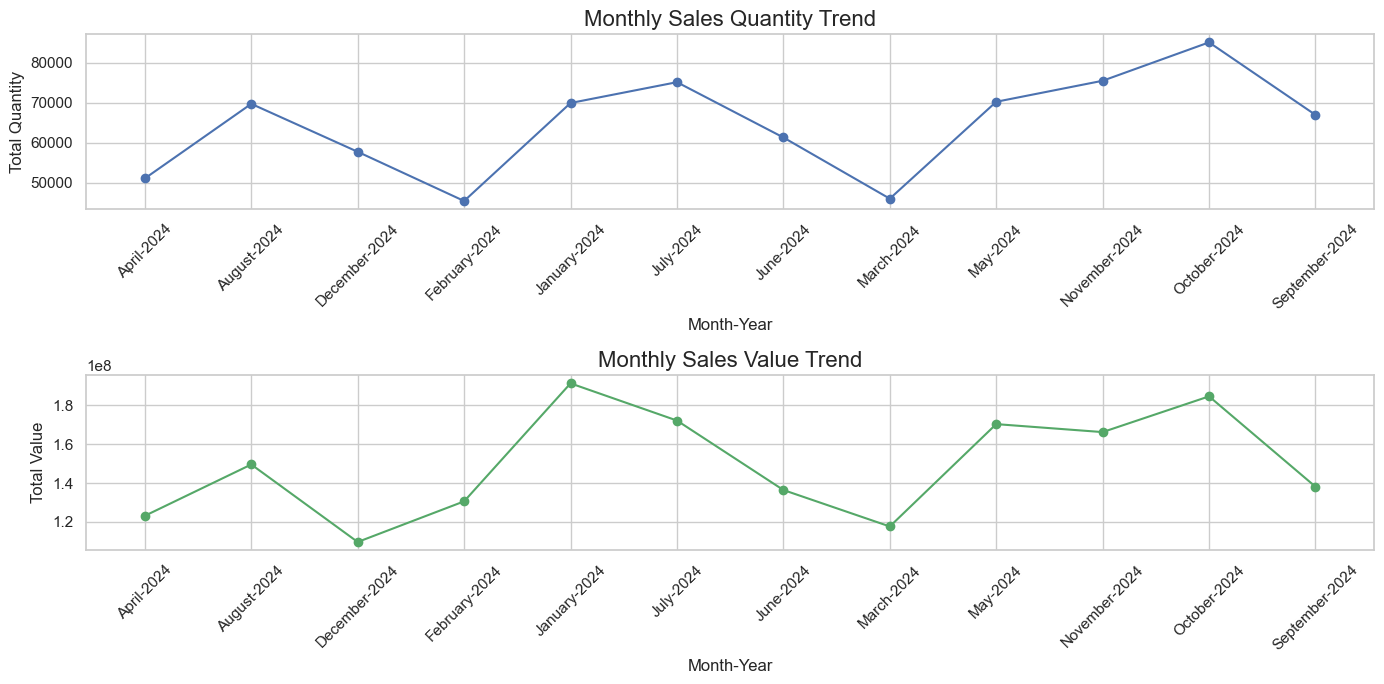

In [25]:
### Set plot style

sb.set(style="whitegrid")

### Set figure size

plt.figure(figsize=(14, 7))

### Plotting the Quantity over Time

plt.subplot(2, 1, 1)  # Two rows, one column, first plot
plt.plot(monthly_data['Month-Year'], monthly_data['QUANTITY'], marker='o', color='b', label='Quantity')
plt.title('Monthly Sales Quantity Trend', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Quantity', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)

### Plotting the Value over Time

plt.subplot(2, 1, 2)  # Two rows, one column, second plot
plt.plot(monthly_data['Month-Year'], monthly_data['TOTAL VALUE'], marker='o', color='g', label='Value')
plt.title('Monthly Sales Value Trend', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Value', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)

### Display the plots
plt.tight_layout()
plt.show()

In [26]:
### Checking best perfoming products based on Quantity

products = df.groupby('ANONYMIZED PRODUCT')['QUANTITY'].count().reset_index()

### Sorting in descending order and selecting the top 5 products

top_5_products = products.sort_values('QUANTITY', ascending=False).head(5)

top_5_products

,ANONYMIZED PRODUCT,QUANTITY
750,Product-e805,25092
338,Product-66e0,18584
476,Product-8f75,15124
213,Product-4156,11616
679,Product-d09c,8856


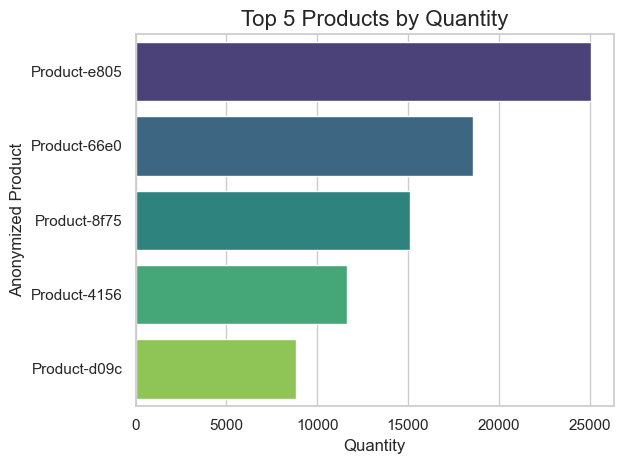

In [27]:
### Visualization
### Creating a bar chart

sb.barplot(x='QUANTITY', y='ANONYMIZED PRODUCT', data=top_5_products, palette='viridis')

### Title and labels

plt.title('Top 5 Products by Quantity', fontsize=16)
plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Anonymized Product', fontsize=12)

### Display the plot

plt.tight_layout()
plt.show()

In [28]:
### Checking best perfoming products based on value

products_value = df.groupby('ANONYMIZED PRODUCT')['TOTAL VALUE'].sum().reset_index()

### Sorting in descending order and selecting the top 5 products

top_5_products_value = products_value.sort_values('TOTAL VALUE', ascending=False).head(5)

top_5_products_value

,ANONYMIZED PRODUCT,TOTAL VALUE
750,Product-e805,268760281
476,Product-8f75,160773305
338,Product-66e0,71038955
127,Product-29ee,69722392
213,Product-4156,57413221


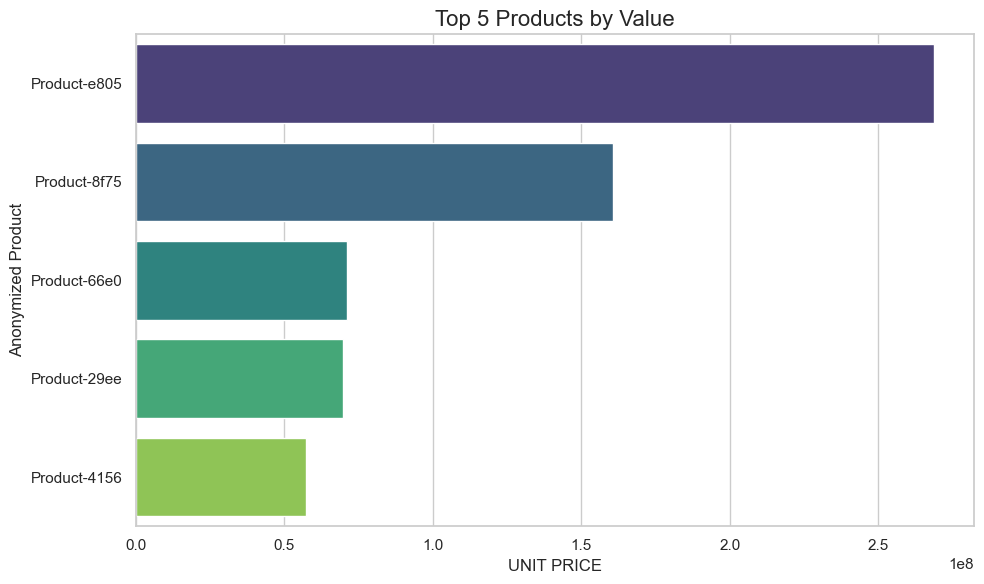

In [29]:
### Visualization
### Set plot size

plt.figure(figsize=(10, 6))

### Creating a bar chart

sb.barplot(x='TOTAL VALUE', y='ANONYMIZED PRODUCT', data=top_5_products_value, palette='viridis')

### Title and labels

plt.title('Top 5 Products by Value', fontsize=16)
plt.xlabel('UNIT PRICE', fontsize=12)
plt.ylabel('Anonymized Product', fontsize=12)

### Display the plot

plt.tight_layout()
plt.show()

### SEGMENTATION ANALYSIS

In [30]:
### Using the RFM analysis for customer segmentation
### Set a reference date for Recency (e.g., the most recent transaction date in the dataset)
reference_date = df['DATE'].max()

### Calculate Recency, Frequency, and Monetary for each business
rfm = df.groupby('ANONYMIZED BUSINESS').agg(
    recency=('DATE', lambda x: (reference_date - x.max()).days),  # Days since last purchase
    frequency=('DATE', 'count'),  # Number of transactions
    monetary=('TOTAL VALUE', 'sum')  # Total spending
).reset_index()

In [31]:
rfm

,ANONYMIZED BUSINESS,recency,frequency,monetary
0,Business-0000,4,8,10445
1,Business-0005,214,1,2645
2,Business-0029,230,6,77340
3,Business-003d,22,31,221761
4,Business-0072,15,101,225056
...,...,...,...,...
4795,Business-ffa9,264,3,6740
4796,Business-ffae,201,5,10530
4797,Business-ffb1,66,105,438115
4798,Business-ffd2,95,24,78548


In [32]:
### Assign quintile scores for each RFM metric

r = pd.qcut(rfm['recency'], q=5, labels=range(5,0,-1))
f = pd.qcut(rfm['frequency'], q=5, labels=range(1,6))
m = pd.qcut(rfm['monetary'], q=5, labels=range(1,6))

rfm = rfm.assign(R=r.values, F=f.values, M=m.values)

rfm.head()

,ANONYMIZED BUSINESS,recency,frequency,monetary,R,F,M
0,Business-0000,4,8,10445,5,3,2
1,Business-0005,214,1,2645,1,1,1
2,Business-0029,230,6,77340,1,2,3
3,Business-003d,22,31,221761,4,4,4
4,Business-0072,15,101,225056,4,5,4


In [33]:
### Calculate RFM Total
rfm['rfm_total'] = rfm['R'].astype(int) + rfm['F'].astype(int) + rfm['M'].astype(int)

In [34]:
rfm

,ANONYMIZED BUSINESS,recency,frequency,monetary,R,F,M,rfm_total
0,Business-0000,4,8,10445,5,3,2,10
1,Business-0005,214,1,2645,1,1,1,3
2,Business-0029,230,6,77340,1,2,3,6
3,Business-003d,22,31,221761,4,4,4,12
4,Business-0072,15,101,225056,4,5,4,13
...,...,...,...,...,...,...,...,...
4795,Business-ffa9,264,3,6740,1,2,1,4
4796,Business-ffae,201,5,10530,1,2,2,5
4797,Business-ffb1,66,105,438115,3,5,5,13
4798,Business-ffd2,95,24,78548,3,4,3,10


In [35]:
### Define a function to categorize the RFM status

def categorize_rfm(total_score):
    if 11 <= total_score <= 15:
        return 'High Value'       # High: Scores between 11 and 15.
    elif 6 <= total_score <= 10:
        return 'Medium Value'     # Medium: Scores between 6 and 10
    else:
        return 'Low Value'        # Low: Scores less than 6
    
### Apply the function to create a 'status' column

rfm['status'] = rfm['rfm_total'].apply(categorize_rfm)

In [36]:
rfm

,ANONYMIZED BUSINESS,recency,frequency,monetary,R,F,M,rfm_total,status
0,Business-0000,4,8,10445,5,3,2,10,Medium Value
1,Business-0005,214,1,2645,1,1,1,3,Low Value
2,Business-0029,230,6,77340,1,2,3,6,Medium Value
3,Business-003d,22,31,221761,4,4,4,12,High Value
4,Business-0072,15,101,225056,4,5,4,13,High Value
...,...,...,...,...,...,...,...,...,...
4795,Business-ffa9,264,3,6740,1,2,1,4,Low Value
4796,Business-ffae,201,5,10530,1,2,2,5,Low Value
4797,Business-ffb1,66,105,438115,3,5,5,13,High Value
4798,Business-ffd2,95,24,78548,3,4,3,10,Medium Value


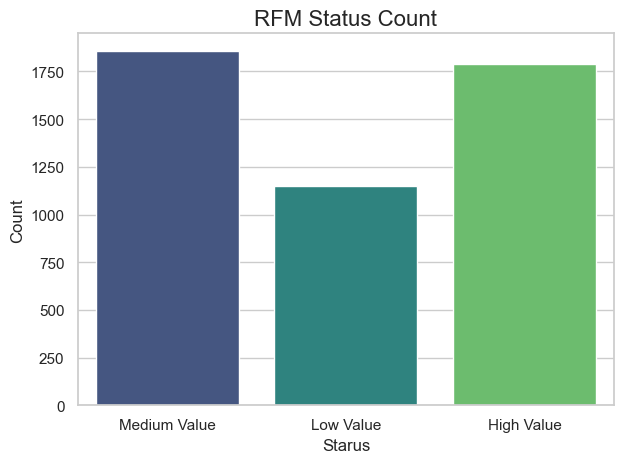

In [34]:
### Visualization
### Creating a bar chart

sb.countplot(x='status', data=rfm, palette='viridis')

### Title and labels

plt.title('RFM Status Count', fontsize=16)
plt.xlabel('Starus', fontsize=12)
plt.ylabel('Count', fontsize=12)

### Display the plot

plt.tight_layout()
plt.show()

### Forecasting the total sales (value) for the next 3 months

In [35]:
new_df = df[['Month-Year', 'TOTAL VALUE']]
new_df.head()

,Month-Year,TOTAL VALUE
0,August-2024,850
1,August-2024,3820
2,August-2024,3670
3,August-2024,2605
4,August-2024,7400


In [36]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333397 entries, 0 to 333404
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Month-Year   333397 non-null  object
 1   TOTAL VALUE  333397 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 7.6+ MB


In [37]:
### Convert 'Month-Year' to datetime

new_df['Month-Year'] = pd.to_datetime(new_df['Month-Year'], format='%B-%Y')

C:\Users\USER\AppData\Local\Temp\ipykernel_12804\2471510080.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['Month-Year'] = pd.to_datetime(new_df['Month-Year'], format='%B-%Y')


In [97]:
Total_df = new_df.groupby('Month-Year')['TOTAL VALUE'].mean().reset_index()

In [98]:
Total_df

,Month-Year,TOTAL VALUE
0,2024-01-01,7324.090255
1,2024-02-01,6749.318435
2,2024-03-01,6044.099882
3,2024-04-01,6047.831558
4,2024-05-01,5998.605626
5,2024-06-01,5250.873942
6,2024-07-01,5494.027405
7,2024-08-01,4943.990515
8,2024-09-01,4263.429766
9,2024-10-01,4697.888389


In [100]:
# Ensure "Month-Year" column is in datetime format
Total_df["Month-Year"] = pd.to_datetime(Total_df["Month-Year"])

<Axes: xlabel='Month-Year'>

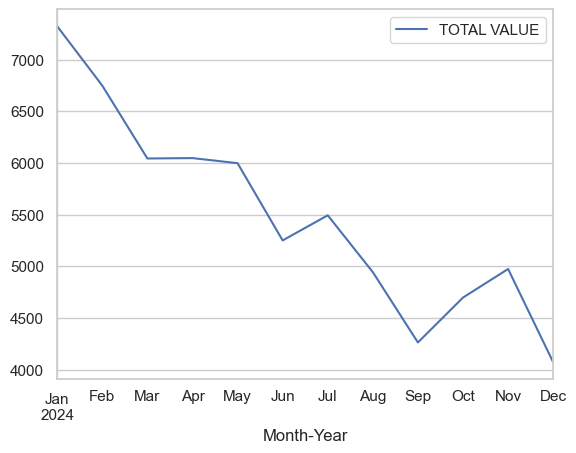

In [101]:
Total_df.plot(x='Month-Year', y='TOTAL VALUE')

In [102]:
### Testing for stationary

from statsmodels.tsa.stattools import adfuller

In [103]:
test_result = adfuller(Total_df['TOTAL VALUE'])

In [104]:
###H0: It's non stationary
###H1: It's stationary

def adfuller_test(total_value):
    result = adfuller(total_value)
    labels = ['ADF Test Statistic', 'p_value', '#Lags Used', 'Number of Obsevations Used']
    for value, label in zip(result,labels):
         print(f'{label}: {value}')  # Proper string formatting
    # Interpretation based on p-value
    if result[1] <= 0.05:
         print('Strong evidence against null hypothesis(H0), reject null hypothesis. Data has no unit root therefor, it is stationary'),
    else:
         print('Weak evidence against null hypothesis(H1), time series has unit root indicating it is non stationary')

In [105]:
adfuller_test(Total_df['TOTAL VALUE'])

ADF Test Statistic: -1.6202829743169225
p_value: 0.4725809483767703
#Lags Used: 2
Number of Obsevations Used: 9
Weak evidence against null hypothesis(H1), time series has unit root indicating it is non stationary


### Differencing

In [106]:
Total_df['Difference'] = Total_df['TOTAL VALUE'].diff()

In [107]:
Total_df

,Month-Year,TOTAL VALUE,Difference
0,2024-01-01,7324.090255,NaN
1,2024-02-01,6749.318435,-574.771819
2,2024-03-01,6044.099882,-705.218554
3,2024-04-01,6047.831558,3.731676
4,2024-05-01,5998.605626,-49.225931
5,2024-06-01,5250.873942,-747.731685
6,2024-07-01,5494.027405,243.153463
7,2024-08-01,4943.990515,-550.036889
8,2024-09-01,4263.429766,-680.560749
9,2024-10-01,4697.888389,434.458622


In [108]:
adfuller_test(Total_df['Difference'].dropna())

ADF Test Statistic: -5.199312871282582
p_value: 8.82052732503156e-06
#Lags Used: 1
Number of Obsevations Used: 9
Strong evidence against null hypothesis(H0), reject null hypothesis. Data has no unit root therefor, it is stationary


<Axes: >

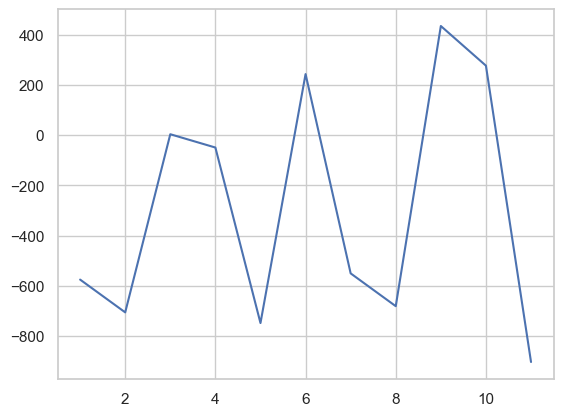

In [109]:
Total_df['Difference'].plot()

### Auto Regressive Model (AR) & Moving Averages (MA)

In [110]:
### For identification of AR model is best done with Partial Autocorrelation (PACF) wheres,
###  identification of MA model is best done with Autocorrelation (ACF).

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

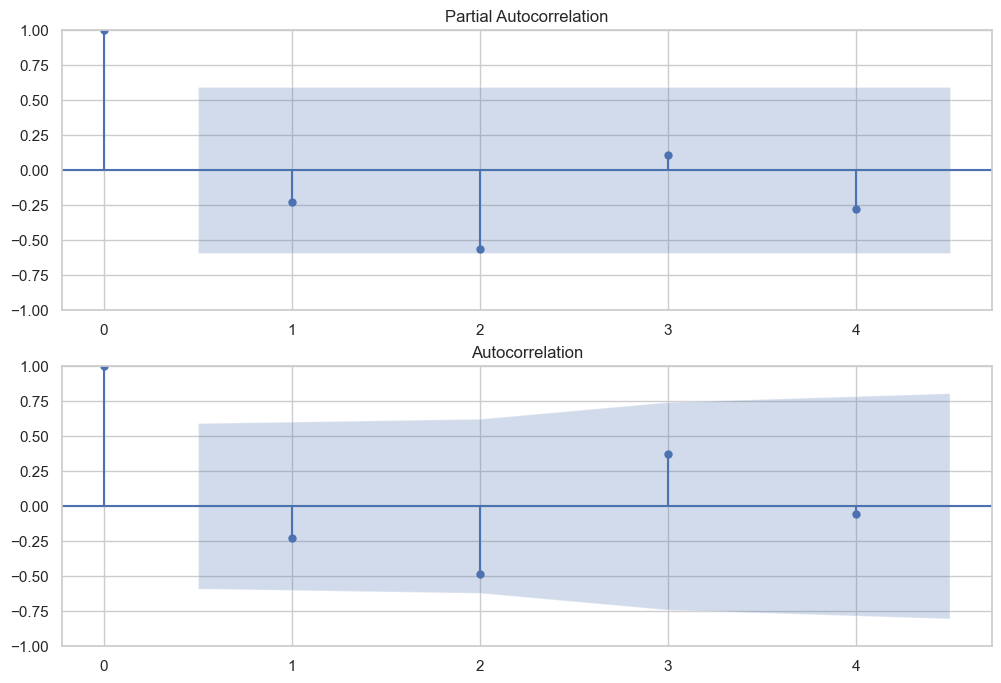

In [111]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_pacf(Total_df['Difference'].iloc[1:], lags = 4, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_acf(Total_df['Difference'].iloc[1:], lags = 4, ax=ax2)

In [112]:
from statsmodels.tsa.arima.model import ARIMA 

In [113]:
model = ARIMA(Total_df['TOTAL VALUE'], order=(1,1,1))
model_fit = model.fit()

C:\Users\USER\anaconda3\Python\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\USER\anaconda3\Python\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [114]:
### Get last date from the column (not the index)
last_date = Total_df["Month-Year"].iloc[-1]

In [115]:
### Creating Forecast Dates
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), 
                               periods=3, freq="MS")

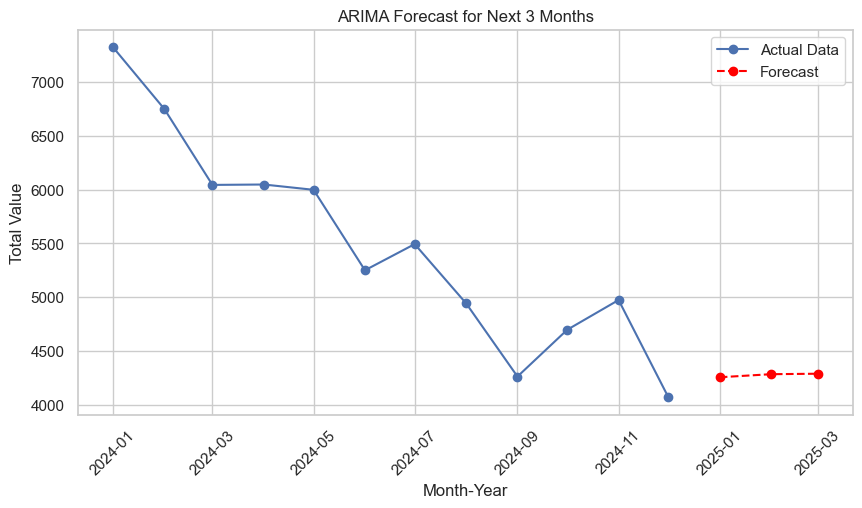

In [116]:
plt.figure(figsize=(10, 5))

# Plot actual data using "Month-Year" column
plt.plot(Total_df["Month-Year"], Total_df["TOTAL VALUE"], label="Actual Data", marker='o')

# Plot forecast
plt.plot(forecast_dates, forecast, label="Forecast", linestyle="dashed", color="red", marker='o')

plt.xlabel("Month-Year")
plt.ylabel("Total Value")
plt.title("ARIMA Forecast for Next 3 Months")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

### Forecasted Values for Next 3 Months (Using ARIMA)
           ### January 2025 → 4,256.78
           ### February 2025 → 4,285.22
           ###  March 2025 → 4,289.60